In [2]:
import numpy as np
import pandas as pd
import seaborn as sns

import matplotlib.pyplot as plt


In [10]:
#loading the dataset
df = pd.read_csv("Train.csv")
# first 5 rows
print(df.shape)
df.head()

(8523, 12)


,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales
0,FDA15,9.30,Low Fat,0.016047,Dairy,249.8092,OUT049,1999,Medium,Tier 1,Supermarket Type1,3735.1380
1,DRC01,5.92,Regular,0.019278,Soft Drinks,48.2692,OUT018,2009,Medium,Tier 3,Supermarket Type2,443.4228
2,FDN15,17.50,Low Fat,0.016760,Meat,141.6180,OUT049,1999,Medium,Tier 1,Supermarket Type1,2097.2700
3,FDX07,19.20,Regular,0.000000,Fruits and Vegetables,182.0950,OUT010,1998,NaN,Tier 3,Grocery Store,732.3800
4,NCD19,8.93,Low Fat,0.000000,Household,53.8614,OUT013,1987,High,Tier 3,Supermarket Type1,994.7052


In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8523 entries, 0 to 8522
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Item_Identifier            8523 non-null   object 
 1   Item_Weight                7060 non-null   float64
 2   Item_Fat_Content           8523 non-null   object 
 3   Item_Visibility            8523 non-null   float64
 4   Item_Type                  8523 non-null   object 
 5   Item_MRP                   8523 non-null   float64
 6   Outlet_Identifier          8523 non-null   object 
 7   Outlet_Establishment_Year  8523 non-null   int64  
 8   Outlet_Size                6113 non-null   object 
 9   Outlet_Location_Type       8523 non-null   object 
 10  Outlet_Type                8523 non-null   object 
 11  Item_Outlet_Sales          8523 non-null   float64
dtypes: float64(4), int64(1), object(7)
memory usage: 799.2+ KB


In [23]:
categorical_cols = list(df.select_dtypes(include=["object", "category"]).columns)
print(df[categorical_cols].dtypes)
print(len(categorical_cols))

Item_Identifier         object
Item_Fat_Content        object
Item_Type               object
Outlet_Identifier       object
Outlet_Size             object
Outlet_Location_Type    object
Outlet_Type             object
dtype: object
7


In [24]:
numerical_cols = list(df.select_dtypes(include=["float","int"]))
print(df[numerical_cols].dtypes)
print(len(numerical_cols))

Item_Weight                  float64
Item_Visibility              float64
Item_MRP                     float64
Outlet_Establishment_Year      int64
Item_Outlet_Sales            float64
dtype: object
5


In [27]:
df.isnull().sum()

Item_Identifier                 0
Item_Weight                  1463
Item_Fat_Content                0
Item_Visibility                 0
Item_Type                       0
Item_MRP                        0
Outlet_Identifier               0
Outlet_Establishment_Year       0
Outlet_Size                  2410
Outlet_Location_Type            0
Outlet_Type                     0
Item_Outlet_Sales               0
dtype: int64

In [30]:
missing_weight = df[df['Item_Weight'].isnull()]
missing_weight

,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales
7,FDP10,NaN,Low Fat,0.127470,Snack Foods,107.7622,OUT027,1985,Medium,Tier 3,Supermarket Type3,4022.7636
18,DRI11,NaN,Low Fat,0.034238,Hard Drinks,113.2834,OUT027,1985,Medium,Tier 3,Supermarket Type3,2303.6680
21,FDW12,NaN,Regular,0.035400,Baking Goods,144.5444,OUT027,1985,Medium,Tier 3,Supermarket Type3,4064.0432
23,FDC37,NaN,Low Fat,0.057557,Baking Goods,107.6938,OUT019,1985,Small,Tier 1,Grocery Store,214.3876
29,FDC14,NaN,Regular,0.072222,Canned,43.6454,OUT019,1985,Small,Tier 1,Grocery Store,125.8362
...,...,...,...,...,...,...,...,...,...,...,...,...
8485,DRK37,NaN,Low Fat,0.043792,Soft Drinks,189.0530,OUT027,1985,Medium,Tier 3,Supermarket Type3,6261.8490
8487,DRG13,NaN,Low Fat,0.037006,Soft Drinks,164.7526,OUT027,1985,Medium,Tier 3,Supermarket Type3,4111.3150
8488,NCN14,NaN,Low Fat,0.091473,Others,184.6608,OUT027,1985,Medium,Tier 3,Supermarket Type3,2756.4120
8490,FDU44,NaN,Regular,0.102296,Fruits and Vegetables,162.3552,OUT019,1985,Small,Tier 1,Grocery Store,487.3656


In [34]:
missing_weight["Item_Type"].value_counts()

Item_Type
Fruits and Vegetables    213
Snack Foods              212
Household                151
Frozen Foods             138
Dairy                    116
Baking Goods             112
Canned                   110
Health and Hygiene        90
Meat                      88
Soft Drinks               71
Breads                    47
Others                    32
Hard Drinks               31
Breakfast                 21
Starchy Foods             18
Seafood                   13
Name: count, dtype: int64

In [32]:
missing_weight["Outlet_Type"].value_counts()

Outlet_Type
Supermarket Type3    935
Grocery Store        528
Name: count, dtype: int64

In [35]:
df["Item_Weight"] = df["Item_Weight"].fillna(df.groupby("Item_Identifier")["Item_Weight"].transform("mean"))

In [36]:
df["Item_Weight"].isnull().sum()

4

In [37]:
df["Item_Weight"] = df["Item_Weight"].fillna(df.groupby("Item_Type")["Item_Weight"].transform("mean"))

In [38]:
df["Item_Weight"].isnull().sum()

0

In [39]:
df["Outlet_Size"].isnull().sum()

2410

In [47]:
df["Outlet_Size"].unique()

array(['Medium', nan, 'High', 'Small'], dtype=object)

In [42]:
missing_out_size = df[df["Outlet_Size"].isnull()]
#missing_out_size

In [46]:
missing_out_size["Item_Type"].value_counts()
missing_out_size["Outlet_Identifier"].value_counts()

Outlet_Identifier
OUT045    929
OUT017    926
OUT010    555
Name: count, dtype: int64

In [48]:
df[df['Outlet_Size'].isnull()]['Outlet_Identifier'].unique()

array(['OUT010', 'OUT045', 'OUT017'], dtype=object)

In [49]:
pd.crosstab(df['Outlet_Type'], df['Outlet_Size'])

Outlet_Size,High,Medium,Small
Outlet_Type,,,
Grocery Store,0,0,528
Supermarket Type1,932,930,1860
Supermarket Type2,0,928,0
Supermarket Type3,0,935,0


In [51]:
df['Outlet_Size'] = df['Outlet_Size'].fillna(
    df.groupby('Outlet_Type')['Outlet_Size'].transform(lambda x: x.mode()[0])
)

In [52]:
df["Outlet_Size"].isnull().sum()

0

In [53]:
df.isnull().sum()

Item_Identifier              0
Item_Weight                  0
Item_Fat_Content             0
Item_Visibility              0
Item_Type                    0
Item_MRP                     0
Outlet_Identifier            0
Outlet_Establishment_Year    0
Outlet_Size                  0
Outlet_Location_Type         0
Outlet_Type                  0
Item_Outlet_Sales            0
dtype: int64

In [54]:
(df['Item_Visibility'] == 0).sum()

526

In [55]:
zero_items = df[df['Item_Visibility'] == 0]['Item_Identifier'].unique()

In [57]:
df[df['Item_Identifier'].isin(zero_items)].groupby('Item_Identifier')['Item_Visibility'].describe()

,count,mean,std,min,25%,50%,75%,max
Item_Identifier,,,,,,,,
DRA12,6.0,0.031956,0.026942,0.0,0.010228,0.041012,0.041161,0.068535
DRA59,8.0,0.134718,0.068300,0.0,0.127693,0.128027,0.149868,0.223985
DRB48,7.0,0.023700,0.012171,0.0,0.024783,0.024849,0.024943,0.041600
DRC13,4.0,0.024409,0.016273,0.0,0.024327,0.032505,0.032587,0.032625
DRC25,7.0,0.048159,0.026139,0.0,0.045353,0.045464,0.060750,0.079440
...,...,...,...,...,...,...,...,...
NCZ18,7.0,0.179644,0.094739,0.0,0.186050,0.186357,0.186636,0.325781
NCZ30,7.0,0.024956,0.012822,0.0,0.026111,0.026180,0.026232,0.043828
NCZ41,5.0,0.051623,0.028859,0.0,0.064368,0.064409,0.064552,0.064786


In [58]:
(df.groupby('Item_Identifier')['Item_Visibility'].max() == 0).sum()

0

In [60]:
df.loc[df['Item_Visibility'] == 0, 'Item_Visibility'] = \
df.groupby('Item_Identifier')['Item_Visibility'].transform('mean')

In [61]:
(df['Item_Visibility'] == 0).sum()

0

In [62]:
df['Outlet_Identifier'].nunique()

10

In [63]:
categorical_cols

['Item_Identifier',
 'Item_Fat_Content',
 'Item_Type',
 'Outlet_Identifier',
 'Outlet_Size',
 'Outlet_Location_Type',
 'Outlet_Type']

In [64]:
df["Item_Fat_Content"].unique()

array(['Low Fat', 'Regular', 'low fat', 'LF', 'reg'], dtype=object)

In [67]:
df["Item_Fat_Content"] = df["Item_Fat_Content"].replace({
    "LF": "Low Fat",
    "low fat": "Low Fat",
    "reg": "Regular"
})

In [69]:
df["Item_Fat_Content"] = df["Item_Fat_Content"].replace({
    "Law Fat": "Low Fat",
    })

In [70]:
df["Item_Fat_Content"].unique()

array(['Low Fat', 'Regular'], dtype=object)

In [71]:
df[['Item_Identifier', 'Item_Category']].head()

KeyError: "['Item_Category'] not in index"

In [72]:
df['Item_Category'] = df['Item_Identifier'].str[:2]

In [73]:
df.head()

,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales,Item_Category
0,FDA15,9.30,Low Fat,0.016047,Dairy,249.8092,OUT049,1999,Medium,Tier 1,Supermarket Type1,3735.1380,FD
1,DRC01,5.92,Regular,0.019278,Soft Drinks,48.2692,OUT018,2009,Medium,Tier 3,Supermarket Type2,443.4228,DR
2,FDN15,17.50,Low Fat,0.016760,Meat,141.6180,OUT049,1999,Medium,Tier 1,Supermarket Type1,2097.2700,FD
3,FDX07,19.20,Regular,0.015274,Fruits and Vegetables,182.0950,OUT010,1998,Small,Tier 3,Grocery Store,732.3800,FD
4,NCD19,8.93,Low Fat,0.008082,Household,53.8614,OUT013,1987,High,Tier 3,Supermarket Type1,994.7052,NC


In [74]:
df['Item_Category'] = df['Item_Category'].map({
    'FD': 'Food',
    'DR': 'Drinks',
    'NC': 'Non-Consumable'
})

In [75]:
df['Item_Category'].unique()

array(['Food', 'Drinks', 'Non-Consumable'], dtype=object)

In [76]:
df.loc[df['Item_Category'] == 'Non-Consumable', 'Item_Fat_Content'] = 'Non-Edible'

In [77]:
df.columns

Index(['Item_Identifier', 'Item_Weight', 'Item_Fat_Content', 'Item_Visibility',
       'Item_Type', 'Item_MRP', 'Outlet_Identifier',
       'Outlet_Establishment_Year', 'Outlet_Size', 'Outlet_Location_Type',
       'Outlet_Type', 'Item_Outlet_Sales', 'Item_Category'],
      dtype='object')

In [78]:
df['Item_Visibility_Mean'] = df.groupby('Item_Identifier')['Item_Visibility'].transform('mean')

df['Item_Visibility_Mean_Ratio'] = df['Item_Visibility'] / df['Item_Visibility_Mean']

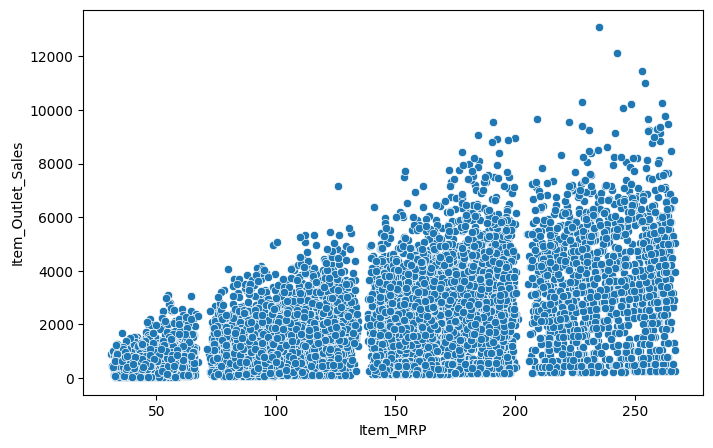

In [79]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
sns.scatterplot(x='Item_MRP', y='Item_Outlet_Sales', data=df)
plt.show()

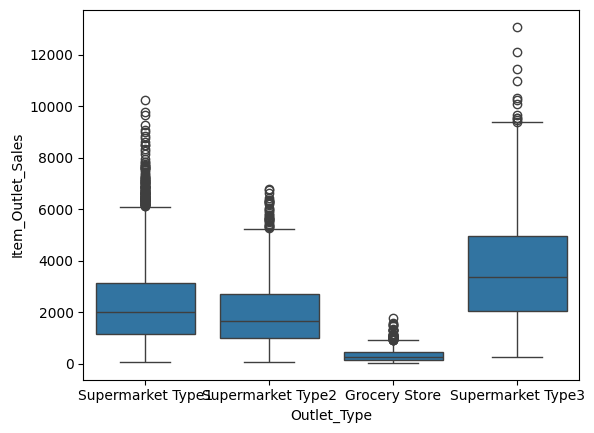

In [80]:
sns.boxplot(x='Outlet_Type', y='Item_Outlet_Sales', data=df)
plt.show()

In [81]:
num_cols = df.select_dtypes(include=['int64','float64']).columns
print(num_cols)

Index(['Item_Weight', 'Item_Visibility', 'Item_MRP',
       'Outlet_Establishment_Year', 'Item_Outlet_Sales',
       'Item_Visibility_Mean', 'Item_Visibility_Mean_Ratio'],
      dtype='object')


In [82]:
corr = df[num_cols].corr()
print(corr)

                             Item_Weight  Item_Visibility  Item_MRP  \
Item_Weight                 1.000000e+00        -0.017912  0.025967   
Item_Visibility            -1.791173e-02         1.000000 -0.004525   
Item_MRP                    2.596697e-02        -0.004525  1.000000   
Outlet_Establishment_Year  -1.341745e-02        -0.075175  0.005020   
Item_Outlet_Sales           1.319810e-02        -0.128449  0.567574   
Item_Visibility_Mean       -1.910990e-02         0.937301 -0.004833   
Item_Visibility_Mean_Ratio  4.368953e-18         0.290853 -0.000271   

                            Outlet_Establishment_Year  Item_Outlet_Sales  \
Item_Weight                                 -0.013417           0.013198   
Item_Visibility                             -0.075175          -0.128449   
Item_MRP                                     0.005020           0.567574   
Outlet_Establishment_Year                    1.000000          -0.049135   
Item_Outlet_Sales                           -0.0491

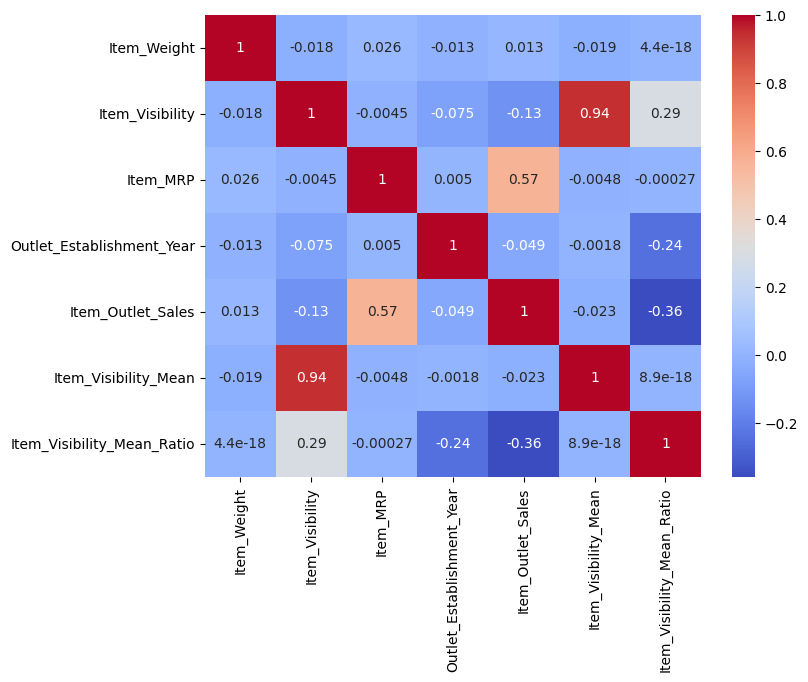

In [83]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.show()

In [84]:
!git remote set-url origin https://github.com/samirakhalil1993/Big-Mark-Sales.git

In [85]:
!git remote -v

origin	https://github.com/samirakhalil1993/Big-Mark-Sales.git (fetch)
origin	https://github.com/samirakhalil1993/Big-Mark-Sales.git (push)


In [86]:
!git push -u origin main

To https://github.com/samirakhalil1993/Big-Mark-Sales.git
 ! [rejected]        main -> main (non-fast-forward)
error: failed to push some refs to 'https://github.com/samirakhalil1993/Big-Mark-Sales.git'
hint: Updates were rejected because the tip of your current branch is behind
hint: its remote counterpart. If you want to integrate the remote changes,
hint: use 'git pull' before pushing again.
hint: See the 'Note about fast-forwards' in 'git push --help' for details.


In [87]:
!git pull origin main --allow-unrelated-histories

Merge made by the 'ort' strategy.
 Test.csv                 | 5682 ++++++++++++++++++++++++++++++
 Train.csv                | 8524 ++++++++++++++++++++++++++++++++++++++++++++++
 bigmart_sales_data.ipynb |  348 ++
 3 files changed, 14554 insertions(+)
 create mode 100644 Test.csv
 create mode 100644 Train.csv
 create mode 100644 bigmart_sales_data.ipynb


From https://github.com/samirakhalil1993/Big-Mark-Sales
 * branch            main       -> FETCH_HEAD


In [88]:
!git push -u origin main

branch 'main' set up to track 'origin/main'.

To https://github.com/samirakhalil1993/Big-Mark-Sales.git
   ea18286..b8a8859  main -> main
